# Random Forest classification on text & handwriting corpus

Train a **TF-IDF + Random Forest** classifier on the smol-doc-analyzer synthetic insurance document corpus:

- **Typed text** — clean Stage A documents (`data/synthetic/documents/`)
- **Handwriting / OCR surface** — character-garbled noisy variants (`data/synthetic/noisy/`) that approximate OCR'd handwriting and scanned forms

**Targets**

1. Primary: predict `document_type` (ACORD-inspired taxonomy)
2. Secondary: predict surface style (`typed` vs `handwriting_ocr`)

This notebook is a lightweight classical baseline alongside the DeBERTa / ViT deep classifiers.

**Multilayer WandB suite** (section 9) runs the same pipeline as the CLI:

0. corpus profile → 1. capacity sweep → 2. dual heads → 3. surface slices →
4. confidence/ECE → 5. feature importance / confusion pairs

Logged under project `smol-doc-analyzer`, run name `rf-notebook-multilayer`.
Corpus seeding does **not** open a WandB run from this notebook.

## 1. Setup

In [1]:
from __future__ import annotations

import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

# Allow running the notebook from notebooks/ or repo root
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Drop cached src.* modules + stale bytecode. Long-lived kernels can keep an
# older random_forest (pre-DEFAULT_PRESET_NAMES) alive even after disk edits.
_rf_pycache = REPO_ROOT / "src" / "classification" / "__pycache__"
if _rf_pycache.is_dir():
    for _pyc in _rf_pycache.glob("random_forest*.pyc"):
        _pyc.unlink(missing_ok=True)
for _mod_name in list(sys.modules):
    if _mod_name == "src" or _mod_name.startswith("src."):
        del sys.modules[_mod_name]

import src.classification.random_forest as _rf

_rf = importlib.reload(_rf)
DEFAULT_PRESET_NAMES = getattr(
    _rf, "DEFAULT_PRESET_NAMES", tuple(_rf.CAPACITY_PRESETS.keys())
)
SURFACE_HANDWRITING_OCR = _rf.SURFACE_HANDWRITING_OCR
SURFACE_TYPED = _rf.SURFACE_TYPED
as_str_list = _rf.as_str_list
assign_split_column = _rf.assign_split_column
build_document_type_pipeline = _rf.build_document_type_pipeline
ensure_seed_corpus = _rf.ensure_seed_corpus
evaluate_classifier = _rf.evaluate_classifier
load_text_handwriting_corpus = _rf.load_text_handwriting_corpus
save_random_forest_bundle = _rf.save_random_forest_bundle
top_tfidf_feature_importances = _rf.top_tfidf_feature_importances
write_predictions_jsonl = _rf.write_predictions_jsonl

from src.classification.train_random_forest import train as train_rf_multilayer
from src.utils.config import Config
from src.utils.llm_client import DEFAULT_FREE_FALLBACK_MODELS
from src.utils.wandb_utils import load_wandb_settings

# OpenRouter routing for corpus seeding / Stage A–B:
# - On HTTP 402 / "requires more credits", GenerationClient sticky-routes to free models.
# - PREFER_FREE_OPENROUTER=True skips paid GENERATION_MODEL entirely (best when credits are gone).
PREFER_FREE_OPENROUTER = True  # set False to try GENERATION_MODEL first, then free on 402
os.environ.setdefault(
    "OPENROUTER_FREE_FALLBACK_MODELS",
    ",".join(DEFAULT_FREE_FALLBACK_MODELS),
)
if PREFER_FREE_OPENROUTER:
    os.environ["OPENROUTER_PREFER_FREE"] = "1"
else:
    os.environ.setdefault("OPENROUTER_PREFER_FREE", "0")

cfg = Config.load()
sns.set_theme(style="whitegrid", context="notebook")
print("repo:", REPO_ROOT)
print("rf module:", _rf.__file__)
print("presets:", DEFAULT_PRESET_NAMES)
print(f"OpenRouter key set: {bool(cfg.openrouter_api_key)}")
print(f"generation model: {cfg.generation_model}")
print(f"prefer free: {cfg.openrouter_prefer_free}")
print(f"free fallbacks: {list(cfg.openrouter_free_fallback_models)}")


repo: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer
rf module: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/src/classification/random_forest.py
presets: ('shallow', 'balanced', 'char_robust', 'hybrid_ocr', 'deep')
OpenRouter key set: True
generation model: anthropic/claude-sonnet-4.5
prefer free: True
free fallbacks: ['openrouter/free', 'meta-llama/llama-3.2-3b-instruct:free', 'openai/gpt-oss-20b:free']


## 2. Ensure corpus (text + handwriting/OCR noise)

Uses `SEED_N=2000` typed documents (~4000 rows with OCR variants). Regenerates when the largest existing corpus is smaller than `SEED_N`.

If `OPENROUTER_API_KEY` is set, Stage A/B may call OpenRouter. With the setup cell above, this notebook prefers **free** OpenRouter models (`openrouter/free` and `:free` fallbacks) so generation still works when paid credits are unavailable; otherwise it falls back to templates.


In [2]:
# Target typed-document count (noisy OCR variants are generated 1:1 → ~2× rows).
SEED_N = 48
SEED = 42

# Regenerates when the largest existing corpus is smaller than SEED_N.
corpus_paths = ensure_seed_corpus(n=SEED_N, seed=SEED, log_wandb=False)
display(pd.Series(corpus_paths, name="path").to_frame())
print(f"requested SEED_N={SEED_N:,} | corpus n={corpus_paths.get('n', '?')} | generated={corpus_paths.get('generated')}")


,path
documents,/Users/morningstar/Desktop/Cold_Storage/smol-d...
noisy,/Users/morningstar/Desktop/Cold_Storage/smol-d...
generated,false
n,240


requested SEED_N=48 | corpus n=240 | generated=false


## 3. Load typed + handwriting/OCR documents

In [3]:
frame = load_text_handwriting_corpus()
frame = assign_split_column(frame)

print(f"rows: {len(frame):,}  |  unique claims: {frame['claim_id'].nunique():,}")
print("sources:", frame.attrs.get("docs_path"), "|", frame.attrs.get("noisy_path"))

display(frame["surface"].value_counts().rename("count").to_frame())
display(
    frame.groupby(["document_type", "surface"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
    .sort_values("total", ascending=False)
)
display(frame["split"].value_counts().rename("count").to_frame())
display(frame.head(3))

rows: 480  |  unique claims: 198
sources: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/documents/documents_from_skeletons_n240_seed42.jsonl | /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/synthetic/noisy/noisy_from_documents_from_skeletons_n240_seed42.jsonl


,count
surface,
typed,240
handwriting_ocr,240


surface,handwriting_ocr,typed,total
document_type,,,
loss_notice,40,40,80
claims_correspondence,38,38,76
supporting_evidence,35,35,70
repair_estimate,33,33,66
application_commercial,26,26,52
certificate_evidence,26,26,52
application_personal,22,22,44
policy_change_endorsement,20,20,40


,count
split,
train,336
val,72
test,72


,record_id,claim_id,text,document_type,surface,is_noisy,split
0,CLM-2026-763588::application_personal::0,CLM-2026-763588,PERSONAL LINES APPLICATION\nClaim Number: CLM-...,application_personal,typed,False,train
1,CLM-2023-397383::loss_notice::1,CLM-2023-397383,AUTOMOBILE LOSS NOTICE\nClaim Number: CLM-2023...,loss_notice,typed,False,train
2,CLM-2025-623940::application_commercial::2,CLM-2025-623940,COMMERCIAL INSURANCE APPLICATION\nClaim Number...,application_commercial,typed,False,train


### Sample: typed vs handwriting/OCR text

In [4]:
sample_id = frame.loc[frame["surface"] == SURFACE_TYPED, "record_id"].iloc[0]
pair = frame[frame["record_id"] == sample_id].set_index("surface")
print("record_id:", sample_id)
print("document_type:", pair.iloc[0]["document_type"])
print("\n--- TYPED ---\n")
print(pair.loc[SURFACE_TYPED, "text"][:700])
print("\n--- HANDWRITING / OCR ---\n")
print(pair.loc[SURFACE_HANDWRITING_OCR, "text"][:700])

record_id: CLM-2026-763588::application_personal::0
document_type: application_personal

--- TYPED ---

PERSONAL LINES APPLICATION
Claim Number: CLM-2026-763588
ACORD Form: 90

APPLICANT
Named Insured: Jordan Lewis
Policy Number: MN-455784-Z
State: MN
Coverage Type: commercial_general_liability
Effective Date: 2025-07-14

VEHICLE / PROPERTY
Policy Number: MN-455784-Z
Named Insured: Jordan Lewis

DRIVERS / OCCUPANTS
Policy Number: MN-455784-Z
Named Insured: Jordan Lewis

PRIOR INSURANCE
Policy Number: MN-455784-Z
Named Insured: Jordan Lewis

Applicant Signature
Prepared for claim CLM-2026-763588

--- HANDWRITING / OCR ---

P~RSO~A¤ LINES APPLICATION
Claim Number: CLM-2026-763588
ACORD Form: 90

APPLICANT
Named Insued: Jordan Lewis
Policy Number: MN-455784-Z
5tte: MN
Coverage Type: commercial_gener~l_liability
Effective Date: 2025-07-14

VEHICLE / PROPERTY
olicy Number: MN-45784-Z
 Named Insured: Jordan LewiV

DRIVMRS / OCCUPANTS
Policy Numbr: MN-455784-Z
Named Insred: Jordan Lewis

 PRI

## 4. Train Random Forest — document type classification

Features: TF-IDF unigrams + bigrams over the document text (typed and OCR surfaces together).

In [5]:
train_df = frame[frame["split"] == "train"].reset_index(drop=True)
val_df = frame[frame["split"] == "val"].reset_index(drop=True)
test_df = frame[frame["split"] == "test"].reset_index(drop=True)

# Fit on train + val (classical baseline); hold out test for final prediction
fit_df = pd.concat([train_df, val_df], ignore_index=True)

doc_clf = build_document_type_pipeline(
    n_estimators=300,
    max_features=20000,
    ngram_range=(1, 2),
    random_state=42,
)
doc_clf.fit(fit_df["text"], fit_df["document_type"])

print(f"fitted on {len(fit_df):,} rows  |  classes: {list(doc_clf.classes_)}")
print(f"TF-IDF vocabulary size: {len(doc_clf.named_steps['tfidf'].vocabulary_):,}")

fitted on 408 rows  |  classes: ['application_commercial', 'application_personal', 'certificate_evidence', 'claims_correspondence', 'loss_notice', 'policy_change_endorsement', 'repair_estimate', 'supporting_evidence']
TF-IDF vocabulary size: 4,517


## 5. Evaluate on held-out test set

In [6]:
doc_metrics = evaluate_classifier(
    doc_clf,
    as_str_list(test_df["text"]),
    as_str_list(test_df["document_type"]),
    labels=list(doc_clf.classes_),
)

print(f"Test accuracy : {doc_metrics['accuracy']:.4f}")
print(f"Macro F1      : {doc_metrics['macro_f1']:.4f}")
print(f"Weighted F1   : {doc_metrics['weighted_f1']:.4f}")
print(f"N test rows   : {doc_metrics['n']}")

report_df = pd.DataFrame(doc_metrics["classification_report"]).T
display(report_df.round(3))

Test accuracy : 1.0000
Macro F1      : 1.0000
Weighted F1   : 1.0000
N test rows   : 72


,precision,recall,f1-score,support
application_commercial,1.0,1.0,1.0,8.0
application_personal,1.0,1.0,1.0,8.0
certificate_evidence,1.0,1.0,1.0,8.0
claims_correspondence,1.0,1.0,1.0,10.0
loss_notice,1.0,1.0,1.0,12.0
policy_change_endorsement,1.0,1.0,1.0,6.0
repair_estimate,1.0,1.0,1.0,10.0
supporting_evidence,1.0,1.0,1.0,10.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,72.0


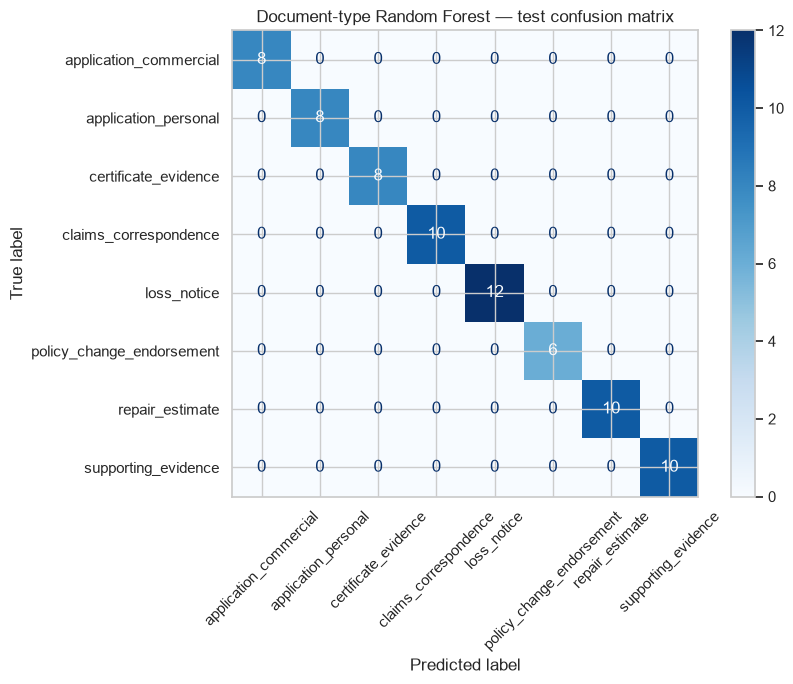

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix=np.asarray(doc_metrics["confusion_matrix"]),
    display_labels=doc_metrics["labels"],
).plot(ax=ax, colorbar=True, cmap="Blues")
# sklearn stubs type xticks_rotation as str only; set degrees on the axes instead.
ax.tick_params(axis="x", labelrotation=45)
ax.set_title("Document-type Random Forest — test confusion matrix")
plt.tight_layout()
plt.show()


### Accuracy by surface (typed vs handwriting/OCR)

,surface,n,accuracy,macro_f1
0,handwriting_ocr,36,1.0,1.0
1,typed,36,1.0,1.0


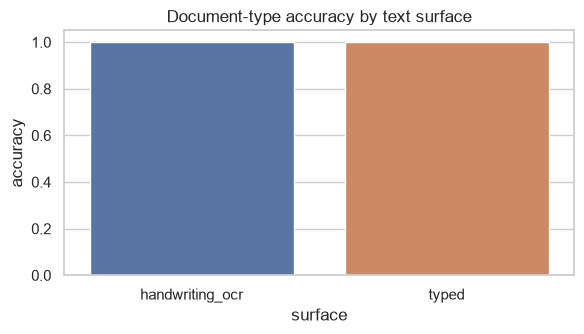

In [8]:
surface_rows = []
for surface, group in test_df.groupby("surface"):
    m = evaluate_classifier(
        doc_clf,
        as_str_list(group["text"]),
        as_str_list(group["document_type"]),
        labels=list(doc_clf.classes_),
    )
    surface_rows.append(
        {
            "surface": surface,
            "n": m["n"],
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
        }
    )
surface_metrics = pd.DataFrame(surface_rows).sort_values("surface")
display(surface_metrics.round(4))

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(data=surface_metrics, x="surface", y="accuracy", hue="surface", ax=ax, legend=False)
ax.set_ylim(0, 1.05)
ax.set_title("Document-type accuracy by text surface")
ax.set_ylabel("accuracy")
plt.tight_layout()
plt.show()

## 6. Predictions

Generate class predictions + confidence for every test document.

In [9]:
y_pred = doc_metrics["predictions"]
y_conf = doc_metrics["max_proba"]

# Build columns explicitly to avoid brittle pandas-stubs rename overloads.
pred_df = pd.DataFrame(
    {
        "record_id": test_df["record_id"].to_numpy(),
        "claim_id": test_df["claim_id"].to_numpy(),
        "surface": test_df["surface"].to_numpy(),
        "true_label": test_df["document_type"].to_numpy(),
        "predicted_label": y_pred,
        "confidence": y_conf,
    }
)
pred_df["correct"] = pred_df["true_label"] == pred_df["predicted_label"]

print("prediction accuracy:", round(float(pred_df["correct"].to_numpy(dtype=float).mean()), 4))
display(pred_df.head(10))

mistakes = pred_df.loc[~pred_df["correct"]].sort_values(by="confidence", ascending=False)
print(f"\nmisclassified: {len(mistakes)} / {len(pred_df)}")
display(mistakes.head(10))


prediction accuracy: 1.0


,record_id,claim_id,surface,true_label,predicted_label,confidence,correct
0,CLM-2026-788540::certificate_evidence::13,CLM-2026-788540,typed,certificate_evidence,certificate_evidence,0.736667,True
1,CLM-2025-731296::supporting_evidence::20,CLM-2025-731296,typed,supporting_evidence,supporting_evidence,0.990000,True
2,CLM-2023-287814::loss_notice::29,CLM-2023-287814,typed,loss_notice,loss_notice,0.993333,True
3,CLM-2025-570914::supporting_evidence::33,CLM-2025-570914,typed,supporting_evidence,supporting_evidence,0.863333,True
4,CLM-2025-368728::loss_notice::37,CLM-2025-368728,typed,loss_notice,loss_notice,1.000000,True
5,CLM-2026-045650::loss_notice::49,CLM-2026-045650,typed,loss_notice,loss_notice,0.990000,True
6,CLM-2026-327767::certificate_evidence::57,CLM-2026-327767,typed,certificate_evidence,certificate_evidence,0.783333,True
7,CLM-2023-033105::repair_estimate::61,CLM-2023-033105,typed,repair_estimate,repair_estimate,0.593333,True
8,CLM-2024-006934::application_commercial::76,CLM-2024-006934,typed,application_commercial,application_commercial,0.800000,True
9,CLM-2023-111091::repair_estimate::84,CLM-2023-111091,typed,repair_estimate,repair_estimate,0.613333,True



misclassified: 0 / 72


,record_id,claim_id,surface,true_label,predicted_label,confidence,correct


## 7. Top TF-IDF features (Random Forest importance)

,feature,importance
0,is,0.015496
1,status,0.012904
2,named,0.012874
3,reserve,0.012052
4,policy,0.011587
5,change,0.011478
6,labor,0.011367
7,amount,0.011040
8,loss,0.010895
9,report,0.010878


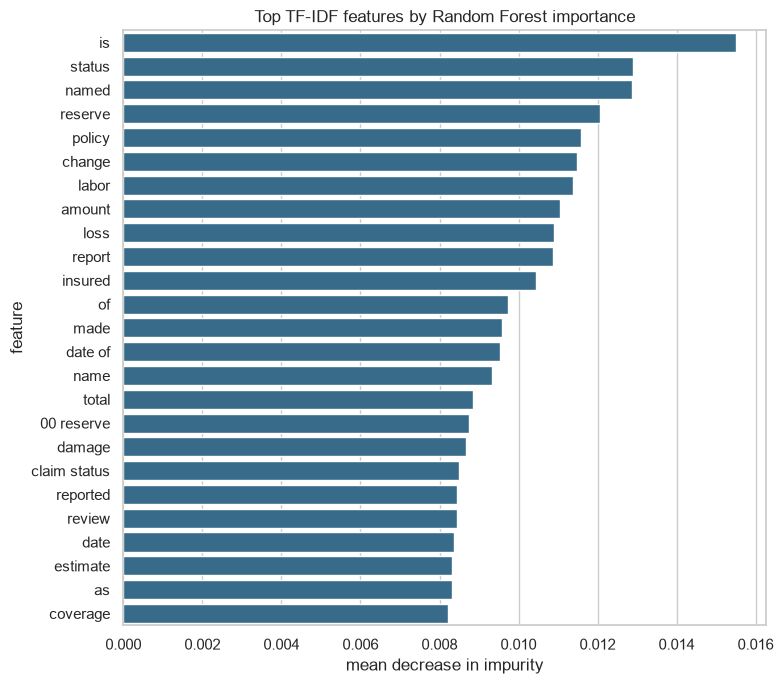

In [10]:
fi = top_tfidf_feature_importances(doc_clf, top_k=25)
display(fi)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=fi, y="feature", x="importance", color="#2a6f97", ax=ax)
ax.set_title("Top TF-IDF features by Random Forest importance")
ax.set_xlabel("mean decrease in impurity")
plt.tight_layout()
plt.show()

## 8. Secondary model — surface style (typed vs handwriting/OCR)

A second Random Forest predicts whether the text looks typed/clean or OCR/handwriting-noisy.

Surface accuracy : 0.6806
Surface macro F1 : 0.6443


,precision,recall,f1-score,support
typed,1.000,0.361,0.531,36.000
handwriting_ocr,0.610,1.000,0.758,36.000
accuracy,0.681,0.681,0.681,0.681
macro avg,0.805,0.681,0.644,72.000
weighted avg,0.805,0.681,0.644,72.000


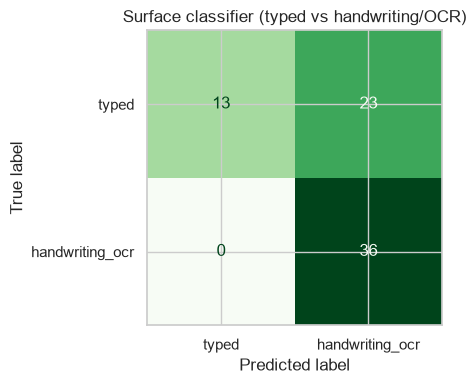

In [11]:
surface_clf = build_document_type_pipeline(
    n_estimators=200,
    max_features=15000,
    ngram_range=(1, 2),
    random_state=42,
)
surface_clf.fit(as_str_list(fit_df["text"]), as_str_list(fit_df["surface"]))

surface_eval = evaluate_classifier(
    surface_clf,
    as_str_list(test_df["text"]),
    as_str_list(test_df["surface"]),
    labels=[SURFACE_TYPED, SURFACE_HANDWRITING_OCR],
)
print(f"Surface accuracy : {surface_eval['accuracy']:.4f}")
print(f"Surface macro F1 : {surface_eval['macro_f1']:.4f}")
display(pd.DataFrame(surface_eval["classification_report"]).T.round(3))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=np.asarray(surface_eval["confusion_matrix"]),
    display_labels=surface_eval["labels"],
).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Surface classifier (typed vs handwriting/OCR)")
plt.tight_layout()
plt.show()

## 9. Multilayer train + WandB (official experiment)

Runs the same multilayer suite as `python -m src.classification.train_random_forest`:

capacity sweep (`shallow` / `balanced` / `deep` / `char_robust`) → best model →
surface head → typed/OCR slices → confidence/ECE → feature importance.

Artifacts land in `models/random_forest_classifier/` and metrics go to WandB under
namespaced keys (`data/`, `sweep/`, `best/`, `slice/`, `confidence/`, `interp/`).

In [12]:
wb_settings = load_wandb_settings()
out_dir = train_rf_multilayer(
    ensure_data=True,
    seed_n=SEED_N,
    presets=list(DEFAULT_PRESET_NAMES),
    wandb_settings=wb_settings,
    wandb_run_name="rf-notebook-multilayer",
)
print("multilayer artifacts ->", out_dir)
print(
    "WandB:",
    f"enabled={wb_settings.enabled}",
    f"mode={wb_settings.mode}",
    f"project={wb_settings.project}",
)
for name in (
    "sweep_results.json",
    "layer_diagnostics.json",
    "eval_metrics.json",
    "train_meta.json",
):
    path = out_dir / name
    print(f"  {name}: {'ok' if path.exists() else 'MISSING'}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: jjburleson (mooslin-university-of-wisconsin-madison) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Tracking run with wandb version 0.28.0


wandb: Run data is saved locally in /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/notebooks/wandb/run-20260722_225221-54ehsvjc
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run rf-notebook-multilayer


...

wandb: uploading media/table/confidence/bins_70_9eed1a3b6fe20d53c8f8.table.json; uploading media/table/best/confusion_matrix_table_96_c25e879a75d59351a652.table.json; uploading wandb-metadata.json; uploading media/table/data/class_counts_8_1a510168fec75bd6d2b7.table.json; uploading output.log (+ 5 more)


wandb: 
wandb: Run history:
wandb:         best/class_f1 ▁▁▁▁▁▁▁▁
wandb:  best/class_precision ▁▁▁▁▁▁▁▁
wandb:     best/class_recall ▁▁▁▁▁▁▁▁
wandb:    best/class_support ▃▃▃▆█▁▆▆
wandb:    best/test_accuracy ▁
wandb:    best/test_macro_f1 ▁
wandb:           best/test_n ▁
wandb: best/test_weighted_f1 ▁
wandb:     best/val_macro_f1 ▁
wandb:        confidence/bin ▁▂▃▃▄▅▆▆▇█
wandb:                   +69 ...
wandb: 
wandb: Run summary:
wandb:         best/class_f1 1
wandb:  best/class_precision 1
wandb:     best/class_recall 1
wandb:    best/class_support 10
wandb:           best/preset shallow
wandb:    best/test_accuracy 1
wandb:    best/test_macro_f1 1
wandb:           best/test_n 72
wandb: best/test_weighted_f1 1
wandb:     best/val_macro_f1 1
wandb:                   +71 ...
wandb: 


wandb: 🚀 View run rf-notebook-multilayer at: https://wandb.ai/mooslin-university-of-wisconsin-madison/smol-doc-analyzer/runs/54ehsvjc
wandb: ⭐️ View project at: https://wandb.ai/mooslin-university-of-wisconsin-madison/smol-doc-analyzer
wandb: Synced 5 W&B file(s), 9 media file(s), 23 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260722_225221-54ehsvjc/logs


multilayer artifacts -> /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/models/random_forest_classifier
WandB: enabled=True mode=online project=smol-doc-analyzer
  sweep_results.json: ok
  layer_diagnostics.json: ok
  eval_metrics.json: ok
  train_meta.json: ok


## 10. Quick inference helper

Predict document type for an arbitrary snippet (typed or OCR-like text).

In [ ]:
def predict_document(text: str, model=doc_clf, top_k: int = 5) -> dict:
    """Return predicted label, confidence, and top-k class probabilities."""
    proba = model.predict_proba([text])[0]
    ranking = sorted(
        zip(model.classes_, map(float, proba)),
        key=lambda x: x[1],
        reverse=True,
    )
    label, conf = ranking[0]
    return {
        "predicted_label": str(label),
        "confidence": float(conf),
        "top_k": [{"label": str(c), "probability": float(p)} for c, p in ranking[:top_k]],
        # keep top3 for backward compatibility with earlier notebook cells / callers
        "top3": [(str(c), float(p)) for c, p in ranking[:3]],
    }


def display_prediction(result: dict, *, title: str = "Document-type prediction") -> None:
    """Pretty-print a predict_document() result in the notebook."""
    from IPython.display import Markdown, display

    label = result["predicted_label"]
    conf = float(result["confidence"])
    rows = result.get("top_k") or [
        {"label": c, "probability": p} for c, p in result.get("top3", [])
    ]
    top_df = pd.DataFrame(rows)
    top_df["probability_pct"] = (top_df["probability"] * 100).round(1)
    top_df["bar"] = top_df["probability"].map(
        lambda p: "█" * int(round(p * 20)) + "░" * (20 - int(round(p * 20)))
    )

    display(
        Markdown(
            f"### {title}\n\n"
            f"**Predicted:** `{label}`  \n"
            f"**Confidence:** {conf:.1%} ({conf:.4f})"
        )
    )
    display(
        top_df.rename(
            columns={
                "label": "class",
                "probability": "p",
                "probability_pct": "p (%)",
                "bar": "distribution",
            }
        )[["class", "p", "p (%)", "distribution"]]
        .style.format({"p": "{:.4f}", "p (%)": "{:.1f}"})
        .hide(axis="index")
    )

    fig, ax = plt.subplots(figsize=(7, max(2.2, 0.45 * len(top_df))))
    ax.barh(
        top_df["label"][::-1],
        top_df["probability"][::-1],
        color="#3b82f6",
        edgecolor="none",
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel("probability")
    ax.set_title(f"Top-{len(top_df)} class probabilities")
    for y, p in enumerate(top_df["probability"][::-1]):
        ax.text(min(p + 0.02, 0.98), y, f"{p:.1%}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


demo = """PROPERTY LOSS NOTICE
Claim Number: CLM-2026-111222
Date of Loss: 2025-11-03
Loss Type: water
Description of Loss: Pipe burst in upstairs bathroom; ceiling damage reported.
Reported By: Jordan Lee
"""

result = predict_document(demo)
display_prediction(result)
